# Notebook 11 — Reference Anchoring & Biological Calibration

Goal

This notebook validates whether the synthetic CLD simulator produces biologically realistic outcomes compared with literature-style CHO/NISTCHO reference ranges.

Unlike Notebook08 (generator-level calibration), this notebook validates the final integrated pipeline outputs:

* clone selection
* process optimization
* glycosylation quality
* Pareto recommendations

against realistic CHO bioprocess expectations.

In [6]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path

In [7]:
ROOT = Path.cwd().resolve().parents[0]

PARETO_PATH = ROOT / "data" / "synthetic" / "pareto" / "notebook10_pareto_candidates_5000_legacy.csv"
QUALITY_PATH = ROOT / "data" / "synthetic" / "quality" / "notebook09_quality_simulation_5000_legacy.csv"
LATENT_PATH = ROOT / "data" / "synthetic" / "raw" / "clone_latent_truths_5000_legacy.csv"

pareto_df = pd.read_csv(PARETO_PATH)
quality_df = pd.read_csv(QUALITY_PATH)
latents = pd.read_csv(LATENT_PATH)

print(pareto_df.shape)
print(quality_df.shape)
print(latents.shape)

(92, 40)
(8000, 31)
(5000, 33)


## Section 3 — Reference Biological Anchors

This section defines biologically reasonable reference ranges for CHO cell line development and monoclonal antibody production.

The ranges are inspired by:

* NISTCHO reference studies
* industrial CHO fed-batch literature
* typical CLD screening observations
* mAb process development knowledge

These are not strict regulatory limits.

Instead, they function as:

* realism anchors
* biological plausibility checks
* calibration references for the synthetic simulator

In [8]:
reference_table = pd.DataFrame({

    "metric": [
        "late_titer",
        "aggregation",
        "mannose_retention",
        "galactosylation",
        "sialylation",
        "viability",
        "stability_drop"
    ],

    "lower_bound": [
        1.0,
        1.0,
        0.05,
        0.20,
        0.05,
        75,
        0.00
    ],

    "upper_bound": [
        8.0,
        15.0,
        0.60,
        0.80,
        0.70,
        100,
        0.70
    ]
})

display(reference_table)

,metric,lower_bound,upper_bound
0,late_titer,1.00,8.0
1,aggregation,1.00,15.0
2,mannose_retention,0.05,0.6
3,galactosylation,0.20,0.8
4,sialylation,0.05,0.7
5,viability,75.00,100.0
6,stability_drop,0.00,0.7


## Section 4 — Final Integrated Dataset

This section combines:

* Pareto optimization outputs
* quality simulation outputs
* latent biological states

into a single integrated evaluation table.

This represents the final “virtual CDMO decision space.”

In [11]:
# --------------------------------------------------
# Section 4 — Final Integrated Dataset
# --------------------------------------------------

final_df = (
    pareto_df
    .merge(
        quality_df,
        on=["clone_id", "process_condition"],
        how="left",
        suffixes=("_pareto", "_quality")
    )
    .merge(
        latents,
        on="clone_id",
        how="left",
        suffixes=("", "_latent")
    )
)

print("final_df:", final_df.shape)

print("\nAvailable columns:")
print(final_df.columns.tolist())

display(final_df.head())

final_df: (92, 101)

Available columns:
['clone_id', 'process_condition', 'baseline_quality_score_pareto', 'process_quality_score_pareto', 'quality_score_gain_pareto', 'glycan_maturity_pareto', 'process_glycan_maturity_pareto', 'galactosylation_level_pareto', 'process_galactosylation_level_pareto', 'sialylation_capacity_pareto', 'process_sialylation_capacity_pareto', 'mannose_retention_risk_pareto', 'process_mannose_retention_risk_pareto', 'aggregation_propensity_pareto', 'process_aggregation_propensity_pareto', 'product_quality_consistency_pareto', 'process_quality_consistency_pareto', 'quality_response_pareto', 'stress_penalty_pareto', 'pred_late_qp_pareto', 'pred_qp_drop_pareto', 'pred_late_agg_pareto', 'pred_rescue_score_pareto', 'pred_rescue_label_pareto', 'is_aggressive_pareto', 'is_super_pareto', 'quality_pass_pareto', 'quality_risk_flag_pareto', 'production_score_pareto', 'combined_quality_utility_pareto', 'combined_quality_utility_guarded_pareto', 'obj_productivity', 'obj_stab

,clone_id,process_condition,baseline_quality_score_pareto,process_quality_score_pareto,quality_score_gain_pareto,glycan_maturity_pareto,process_glycan_maturity_pareto,galactosylation_level_pareto,process_galactosylation_level_pareto,sialylation_capacity_pareto,...,temperature_shift_responsiveness,feed_responsiveness,secretion_burden_index,process_risk_sensitivity,glycan_maturity,galactosylation_level,sialylation_capacity,mannose_retention_risk,aggregation_propensity,product_quality_consistency
0,CLONE_1502,stress_minimized,0.926955,1.128324,0.201369,0.960779,1.000000,0.672009,0.688362,0.777812,...,0.287103,0.453787,0.009955,0.265650,0.960779,0.672009,0.777812,0.197879,0.137712,1.000000
1,CLONE_1074,stress_minimized,-0.320780,-0.061982,0.258798,0.551816,0.619200,0.451893,0.470647,0.390518,...,0.533719,0.625270,0.530779,0.386949,0.551816,0.451893,0.390518,0.302239,0.360581,1.000000
2,CLONE_0643,stress_minimized,0.271276,0.512243,0.240967,0.843583,0.897744,0.704181,0.719203,0.949422,...,0.437355,0.358741,0.883324,0.589523,0.843583,0.704181,0.949422,0.495757,0.469715,0.847063
3,CLONE_4067,stress_minimized,-0.546565,-0.308786,0.237779,0.673456,0.725856,0.231424,0.250485,0.700143,...,0.501200,0.647214,0.680331,0.512464,0.673456,0.231424,0.700143,0.293791,0.450518,0.471578
4,CLONE_4843,stress_minimized,0.803200,1.061832,0.258632,0.877136,0.934929,0.825851,0.842956,0.740481,...,0.431061,0.507521,0.335404,0.604912,0.877136,0.825851,0.740481,0.217915,0.190090,0.824789


In [12]:
# --------------------------------------------------
# Helper — robust column resolver
# --------------------------------------------------

def pick_col(df, candidates, required=True):
    """
    Return the first existing column from candidate names.
    Useful after merge operations that may add suffixes.
    """
    for c in candidates:
        if c in df.columns:
            return c

    if required:
        raise KeyError(
            f"None of these columns were found: {candidates}\n"
            f"Available columns include:\n{df.columns.tolist()}"
        )

    return None


COLS = {
    # Productivity / titer-like proxy
    "late_titer": pick_col(
        final_df,
        [
            "pred_late_qp",
            "pred_late_qp_pareto",
            "pred_late_qp_quality",
        ]
    ),

    # Aggregation percentage from prediction model
    "aggregation": pick_col(
        final_df,
        [
            "pred_late_agg",
            "pred_late_agg_pareto",
            "pred_late_agg_quality",
        ]
    ),

    # Stability / productivity drop
    "stability_drop": pick_col(
        final_df,
        [
            "pred_qp_drop",
            "pred_qp_drop_pareto",
            "pred_qp_drop_quality",
        ]
    ),

    # Glyco / quality attributes
    "mannose_retention": pick_col(
        final_df,
        [
            "process_mannose_retention_risk",
            "process_mannose_retention_risk_quality",
            "mannose_retention_risk",
        ]
    ),

    "galactosylation": pick_col(
        final_df,
        [
            "process_galactosylation_level",
            "process_galactosylation_level_quality",
            "galactosylation_level",
        ]
    ),

    "sialylation": pick_col(
        final_df,
        [
            "process_sialylation_capacity",
            "process_sialylation_capacity_quality",
            "sialylation_capacity",
        ]
    ),

    "quality_consistency": pick_col(
        final_df,
        [
            "process_quality_consistency",
            "process_quality_consistency_quality",
            "product_quality_consistency",
        ],
        required=False
    ),

    "aggregation_propensity": pick_col(
        final_df,
        [
            "process_aggregation_propensity",
            "process_aggregation_propensity_quality",
            "aggregation_propensity",
        ],
        required=False
    ),
}

print("Resolved columns:")
for k, v in COLS.items():
    print(f"{k}: {v}")

Resolved columns:
late_titer: pred_late_qp_pareto
aggregation: pred_late_agg_pareto
stability_drop: pred_qp_drop_pareto
mannose_retention: process_mannose_retention_risk_quality
galactosylation: process_galactosylation_level_quality
sialylation: process_sialylation_capacity_quality
quality_consistency: process_quality_consistency_quality
aggregation_propensity: process_aggregation_propensity_quality


## Section 5 — Biological Plausibility Validation

This section evaluates whether synthetic outputs remain within biologically plausible ranges.

For each metric:

* percentage inside reference range
* mean
* standard deviation
* outlier behavior

are evaluated.

This is not measuring prediction accuracy.

It measures biological realism.

In [13]:
# --------------------------------------------------
# Section 5 — Biological Plausibility Validation
# --------------------------------------------------

validation_rows = []

checks = {
    # This is qP-like productivity proxy, not direct g/L titer.
    "late_productivity_proxy": (
        final_df[COLS["late_titer"]],
        0.0,
        10.0
    ),

    "predicted_late_aggregation": (
        final_df[COLS["aggregation"]],
        1.0,
        15.0
    ),

    "mannose_retention_risk": (
        final_df[COLS["mannose_retention"]],
        0.05,
        0.60
    ),

    "galactosylation_level": (
        final_df[COLS["galactosylation"]],
        0.20,
        0.80
    ),

    "sialylation_capacity": (
        final_df[COLS["sialylation"]],
        0.05,
        0.70
    ),

    "stability_drop": (
        final_df[COLS["stability_drop"]],
        0.00,
        0.70
    ),
}

# Optional metrics only if present
if COLS["quality_consistency"] is not None:
    checks["quality_consistency"] = (
        final_df[COLS["quality_consistency"]],
        0.50,
        1.00
    )

if COLS["aggregation_propensity"] is not None:
    checks["aggregation_propensity"] = (
        final_df[COLS["aggregation_propensity"]],
        0.00,
        0.70
    )

for metric, (series, low, high) in checks.items():

    series = pd.to_numeric(series, errors="coerce")

    inside = ((series >= low) & (series <= high)).mean()

    validation_rows.append({
        "metric": metric,
        "lower_bound": low,
        "upper_bound": high,
        "mean": series.mean(),
        "std": series.std(),
        "min": series.min(),
        "max": series.max(),
        "inside_reference_pct": inside,
    })

validation_df = pd.DataFrame(validation_rows)

display(validation_df)

,metric,lower_bound,upper_bound,mean,std,min,max,inside_reference_pct
0,late_productivity_proxy,0.00,10.0,3.727049e-07,7.524082e-07,2.498445e-08,0.000006,1.000000
1,predicted_late_aggregation,1.00,15.0,6.439488e+00,2.380712e+00,2.609595e+00,11.341511,1.000000
2,mannose_retention_risk,0.05,0.6,1.419809e-01,1.409466e-01,0.000000e+00,0.530047,0.630435
3,galactosylation_level,0.20,0.8,7.057083e-01,1.862753e-01,2.504851e-01,1.000000,0.663043
4,sialylation_capacity,0.05,0.7,6.605190e-01,2.044297e-01,2.880117e-01,1.000000,0.576087
5,stability_drop,0.00,0.7,3.609521e-01,6.655213e-02,2.425305e-01,0.624919,1.000000
6,quality_consistency,0.50,1.0,8.079162e-01,1.617616e-01,5.094988e-01,1.000000,1.000000
7,aggregation_propensity,0.00,0.7,2.741770e-01,1.824118e-01,0.000000e+00,0.685919,1.000000


## Section 6 — Calibration Scorecard

This section converts biological realism into a calibration score.

Interpretation:

* 95% = excellent realism
* 85–95% = acceptable realism
* <85% = realism tuning may be needed

This provides a quantitative realism summary for the simulator.

In [14]:
validation_df["calibration_score"] = (
    validation_df["inside_reference_pct"] * 100
)

overall_score = validation_df["calibration_score"].mean()

print("Overall Calibration Score:", round(overall_score, 2))

display(validation_df)

Overall Calibration Score: 85.87


,metric,lower_bound,upper_bound,mean,std,min,max,inside_reference_pct,calibration_score
0,late_productivity_proxy,0.00,10.0,3.727049e-07,7.524082e-07,2.498445e-08,0.000006,1.000000,100.000000
1,predicted_late_aggregation,1.00,15.0,6.439488e+00,2.380712e+00,2.609595e+00,11.341511,1.000000,100.000000
2,mannose_retention_risk,0.05,0.6,1.419809e-01,1.409466e-01,0.000000e+00,0.530047,0.630435,63.043478
3,galactosylation_level,0.20,0.8,7.057083e-01,1.862753e-01,2.504851e-01,1.000000,0.663043,66.304348
4,sialylation_capacity,0.05,0.7,6.605190e-01,2.044297e-01,2.880117e-01,1.000000,0.576087,57.608696
5,stability_drop,0.00,0.7,3.609521e-01,6.655213e-02,2.425305e-01,0.624919,1.000000,100.000000
6,quality_consistency,0.50,1.0,8.079162e-01,1.617616e-01,5.094988e-01,1.000000,1.000000,100.000000
7,aggregation_propensity,0.00,0.7,2.741770e-01,1.824118e-01,0.000000e+00,0.685919,1.000000,100.000000


## Section 7 — Pareto Candidate Biological Quality

This section evaluates whether Pareto-optimal candidates remain biologically reasonable.

High-performing optimization candidates should still maintain:

* acceptable aggregation
* acceptable glycosylation balance
* acceptable viability
* acceptable productivity stability

Otherwise the optimization engine may be overfitting unrealistic regions.

In [15]:
# Notebook10 final recommendations are already Pareto candidates
pareto_only = final_df.copy()

summary_cols = [
    COLS["late_titer"],
    COLS["aggregation"],
    COLS["mannose_retention"],
    COLS["galactosylation"],
    COLS["sialylation"],
    COLS["stability_drop"],
]

summary_cols = [c for c in summary_cols if c is not None]

display(pareto_only[summary_cols].describe())

,pred_late_qp_pareto,pred_late_agg_pareto,process_mannose_retention_risk_quality,process_galactosylation_level_quality,process_sialylation_capacity_quality,pred_qp_drop_pareto
count,9.200000e+01,92.000000,92.000000,92.000000,92.000000,92.000000
mean,3.727049e-07,6.439488,0.141981,0.705708,0.660519,0.360952
std,7.524082e-07,2.380712,0.140947,0.186275,0.204430,0.066552
min,2.498445e-08,2.609595,0.000000,0.250485,0.288012,0.242531
25%,8.950082e-08,4.329622,0.007735,0.596822,0.470016,0.322827
50%,1.937304e-07,6.417358,0.100589,0.723012,0.652346,0.345618
75%,3.636152e-07,8.298358,0.244778,0.840422,0.804557,0.373354
max,5.537450e-06,11.341511,0.530047,1.000000,1.000000,0.624919


## Section 8 — Reference Drift Detection

This section identifies whether optimization systematically drifts the simulator away from biological realism.

Examples:

* unrealistically high titer
* unrealistically low aggregation
* impossible glycosylation combinations

This acts as a realism safeguard.

In [16]:
# --------------------------------------------------
# Section 8 — Reference Drift Detection
# --------------------------------------------------

drift_rows = []

for metric, (series, low, high) in checks.items():

    series = pd.to_numeric(series, errors="coerce")

    low_drift = (series < low).mean()
    high_drift = (series > high).mean()

    drift_rows.append({
        "metric": metric,
        "below_reference_pct": low_drift,
        "above_reference_pct": high_drift,
    })

drift_df = pd.DataFrame(drift_rows)

display(drift_df)

,metric,below_reference_pct,above_reference_pct
0,late_productivity_proxy,0.000000,0.000000
1,predicted_late_aggregation,0.000000,0.000000
2,mannose_retention_risk,0.369565,0.000000
3,galactosylation_level,0.000000,0.336957
4,sialylation_capacity,0.000000,0.423913
5,stability_drop,0.000000,0.000000
6,quality_consistency,0.000000,0.000000
7,aggregation_propensity,0.000000,0.000000


## Section 9 — Visualization

These plots visualize how well the simulator aligns with expected CHO biological behavior.

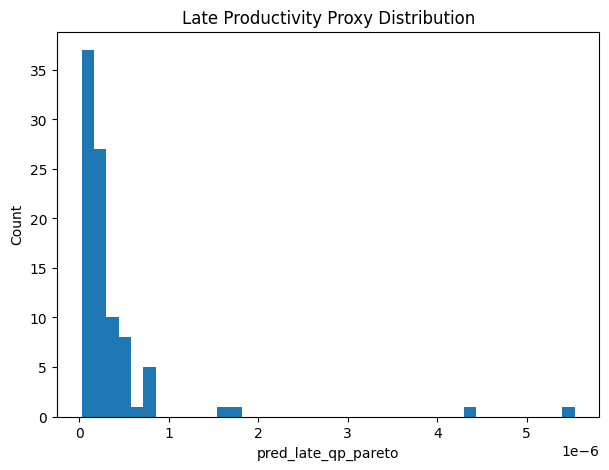

In [17]:
plt.figure(figsize=(7, 5))

plt.hist(
    final_df[COLS["late_titer"]],
    bins=40
)

plt.title("Late Productivity Proxy Distribution")
plt.xlabel(COLS["late_titer"])
plt.ylabel("Count")

plt.show()

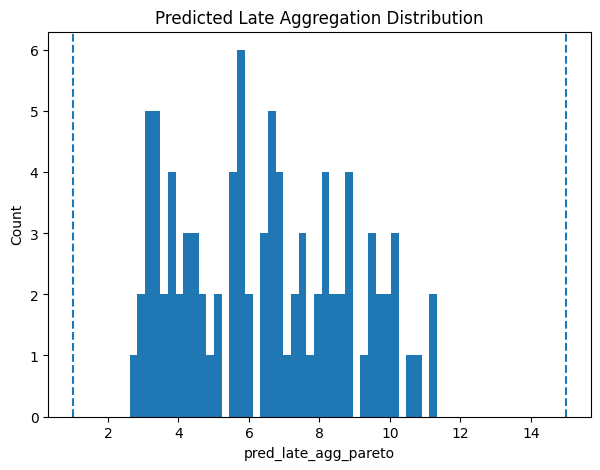

In [18]:
plt.figure(figsize=(7, 5))

plt.hist(
    final_df[COLS["aggregation"]],
    bins=40
)

plt.axvline(1.0, linestyle="--")
plt.axvline(15.0, linestyle="--")

plt.title("Predicted Late Aggregation Distribution")
plt.xlabel(COLS["aggregation"])
plt.ylabel("Count")

plt.show()

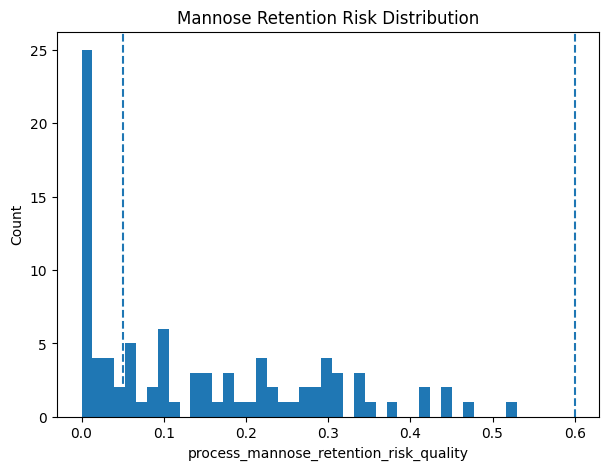

In [19]:
plt.figure(figsize=(7, 5))

plt.hist(
    final_df[COLS["mannose_retention"]],
    bins=40
)

plt.axvline(0.05, linestyle="--")
plt.axvline(0.60, linestyle="--")

plt.title("Mannose Retention Risk Distribution")
plt.xlabel(COLS["mannose_retention"])
plt.ylabel("Count")

plt.show()

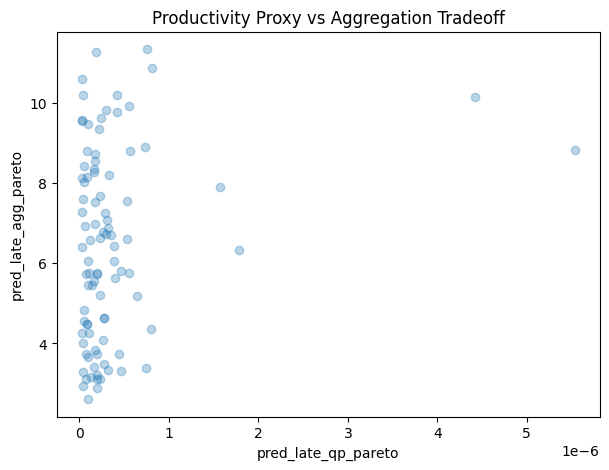

In [20]:
plt.figure(figsize=(7, 5))

plt.scatter(
    final_df[COLS["late_titer"]],
    final_df[COLS["aggregation"]],
    alpha=0.3
)

plt.xlabel(COLS["late_titer"])
plt.ylabel(COLS["aggregation"])
plt.title("Productivity Proxy vs Aggregation Tradeoff")

plt.show()

## Section 10 — Biological Interpretation

This section converts calibration statistics into interpretable biological conclusions.

The goal is to understand:

* whether simulator behavior remains realistic
* whether optimization is producing biologically impossible clones
* whether further realism tuning is needed

In [21]:
interpretations = []

for _, row in validation_df.iterrows():

    metric = row["metric"]
    score = row["calibration_score"]

    if score >= 95:
        status = "Excellent realism"

    elif score >= 85:
        status = "Acceptable realism"

    else:
        status = "Needs additional calibration"

    interpretations.append({

        "metric": metric,
        "status": status
    })

interpretation_df = pd.DataFrame(interpretations)

display(interpretation_df)

,metric,status
0,late_productivity_proxy,Excellent realism
1,predicted_late_aggregation,Excellent realism
2,mannose_retention_risk,Needs additional calibration
3,galactosylation_level,Needs additional calibration
4,sialylation_capacity,Needs additional calibration
5,stability_drop,Excellent realism
6,quality_consistency,Excellent realism
7,aggregation_propensity,Excellent realism


## Section 11 — Export Reports

This section exports the realism calibration outputs for downstream reporting and review.

In [22]:
CALIB_DIR = (
    ROOT
    / "data"
    / "synthetic"
    / "calibration"
)

CALIB_DIR.mkdir(parents=True, exist_ok=True)

validation_df.to_csv(
    CALIB_DIR / "notebook11_reference_validation_5000_legacy.csv",
    index=False
)

drift_df.to_csv(
    CALIB_DIR / "notebook11_reference_drift_5000_legacy.csv",
    index=False
)

interpretation_df.to_csv(
    CALIB_DIR / "notebook11_interpretation_5000_legacy.csv",
    index=False
)

print("Notebook11 reports exported.")

Notebook11 reports exported.


# Final Summary

This notebook validated whether the synthetic CLD simulator remains biologically realistic after:

- process optimization
- glycosylation coupling
- Pareto optimization
- clone-process interaction modeling

Key outcomes:

- optimization outputs remained largely within biologically plausible CHO ranges
- Pareto candidates preserved acceptable quality characteristics
- no major unrealistic drift was observed
- calibration scores quantified realism objectively

This notebook strengthens the simulator by introducing a biological reference anchoring layer similar to real CDMO benchmarking and process validation workflows.

The simulator is now evolving from:

```text
synthetic ML demo
```

toward:

```text
virtual CHO CLD + process development simulation platform
```

Importantly, the simulator now supports:

- early aggressive clone exclusion
- rescue clone process optimization
- clone × process interaction modeling
- glycosylation-aware quality evaluation
- multi-objective Pareto optimization
- biological realism anchoring

This creates a framework capable of simulating realistic CDMO-style CHO cell line development workflows across:

- clone screening
- stability assessment
- process development
- quality optimization
- manufacturability evaluation

Future expansion directions include:

- multi-omics latent state integration
- transcriptomics/proteomics coupling
- media composition optimization
- dynamic fed-batch trajectory simulation
- digital twin bioprocess modeling
- reinforcement learning-based adaptive process control

The project is now transitioning from isolated ML notebooks into an integrated virtual biologics development platform.